# Notebook 04 — Regional aperiodic maps

Aggregates channel-level specparam results to the region level for both datasets,
then produces the main aperiodic atlas figures (Figures 2 & 3 of Chapter 2).

**Inputs** (from notebooks 02 & 03):
- `data/interim/specparam_ieeg_ch_summary.csv`
- `data/interim/specparam_sources_ch_summary.csv`

**Outputs**:
- `data/interim/region_aperiodic_ieeg.csv`
- `data/interim/region_aperiodic_sources.csv`
- Figure 2: Exponent by region (iEEG and sources)
- Figure 3: Offset by region (iEEG and sources)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

PROJECT_ROOT = Path("../../").resolve()
INTERIM_DIR  = PROJECT_ROOT / "data" / "interim"

In [2]:
R2_THRESHOLD = 0.80  # only include good fits in regional summaries

# Load channel-level summaries
ieeg_ch    = pd.read_csv(INTERIM_DIR / "specparam_ieeg_ch_summary.csv")
sources_ch = pd.read_csv(INTERIM_DIR / "specparam_sources_ch_summary.csv")

print("iEEG:   ", ieeg_ch.shape, "  columns:", ieeg_ch.columns.tolist())
print("Sources:", sources_ch.shape, "  columns:", sources_ch.columns.tolist())

iEEG:    (1772, 17)   columns: ['ID', 'offset', 'exponent', 'error_mae', 'gof_rsquared', 'ch_name', 'Region_x', 'Region name', 'Lobe', 'Electrode type', 'Patient', 'Hemisphere', 'Region_y', 'x', 'y', 'z', 'good_fit']
Sources: (1444, 12)   columns: ['ID', 'offset', 'exponent', 'error_mae', 'gof_rsquared', 'ch_name', 'subject', 'roi_number', 'hemisphere', 'Region name', 'Lobe', 'good_fit']


## 1. Aggregate by region

Summarise with **median** (robust to outlier channels) and interquartile range.
Only channels passing the R² threshold are included.

In [3]:
def region_summary(df, region_col="Region name", lobe_col="Lobe"):
    """Median exponent and offset per region from good-fit channels."""
    good = df[df["good_fit"] == True].copy() if "good_fit" in df.columns else df.copy()
    good = good.dropna(subset=[region_col, "exponent", "offset"])

    grp = good.groupby([region_col, lobe_col], as_index=False)
    summary = grp.agg(
        exponent_median = ("exponent", "median"),
        exponent_iqr    = ("exponent", lambda x: x.quantile(0.75) - x.quantile(0.25)),
        exponent_n      = ("exponent", "count"),
        offset_median   = ("offset", "median"),
        offset_iqr      = ("offset", lambda x: x.quantile(0.75) - x.quantile(0.25)),
    )
    return summary


ieeg_region    = region_summary(ieeg_ch)
sources_region = region_summary(sources_ch)

print("iEEG regions:",    len(ieeg_region))
print("Source regions:",  len(sources_region))
ieeg_region.head(5)

iEEG regions: 38
Source regions: 38


,Region name,Lobe,exponent_median,exponent_iqr,exponent_n,offset_median,offset_iqr
0,Amygdala,Temporal,2.196076,0.321127,6,2.600975,0.601299
1,Angular gyrus,Parietal,2.144485,0.423415,53,2.755929,1.062782
2,Anterior cingulate,Frontal,2.229888,0.309135,31,2.354695,1.125490
3,Anterior insula,Insula,2.160249,0.301598,71,2.550545,0.796464
4,Calcarine cortex,Occipital,2.217683,0.354226,12,2.893075,0.712392


## 2. Figure 2 — Exponent by region

Horizontal bar charts sorted by exponent, coloured by lobe.  
Top panel: iEEG. Bottom panel: reconstructed sources.

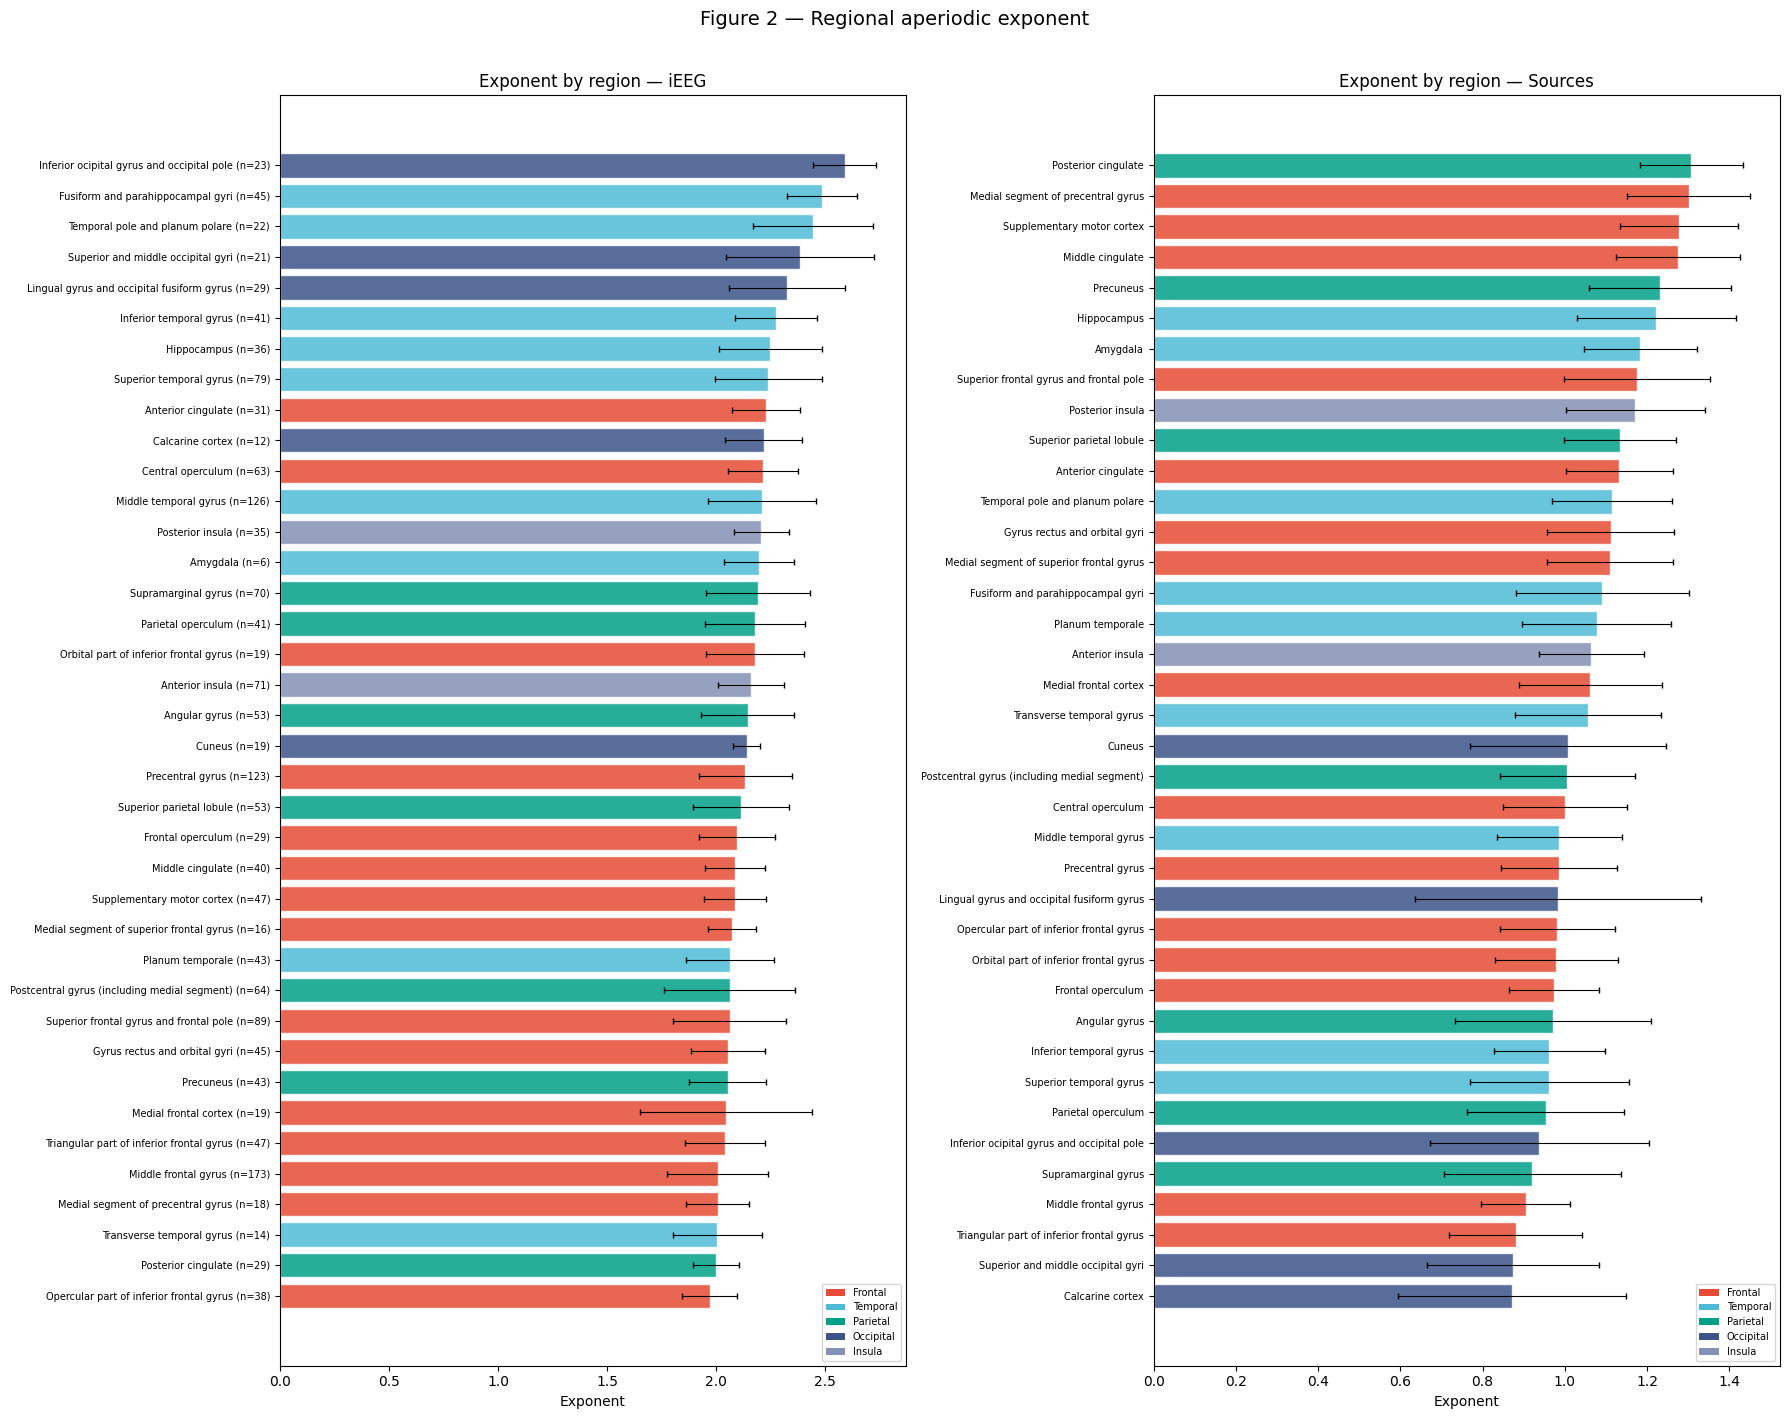

In [4]:
# Lobe colour map
LOBE_COLORS = {
    "Frontal":   "#E64B35",
    "Temporal":  "#4DBBD5",
    "Parietal":  "#00A087",
    "Occipital": "#3C5488",
    "Limbic":    "#F39B7F",
    "Insula":    "#8491B4",
    "Other":     "#91D1C2",
}

def lobe_color(lobe):
    return LOBE_COLORS.get(str(lobe), LOBE_COLORS["Other"])


def plot_region_bars(region_df, param="exponent", title="", ax=None, show_n=True):
    """Horizontal bar chart of a parameter sorted by its median value."""
    df = region_df.sort_values(f"{param}_median").copy()
    colors = [lobe_color(l) for l in df["Lobe"]]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 0.35 * len(df) + 1))

    y = np.arange(len(df))
    ax.barh(y, df[f"{param}_median"], color=colors, alpha=0.85, edgecolor="white")
    ax.errorbar(
        df[f"{param}_median"], y,
        xerr=df[f"{param}_iqr"] / 2,
        fmt="none", color="black", linewidth=0.8, capsize=2
    )
    labels = df["Region name"]
    if show_n and f"{param}_n" in df.columns:
        labels = [f"{r} (n={n})" for r, n in zip(df["Region name"], df[f"{param}_n"])]
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel(param.capitalize())
    ax.set_title(title)

    # Lobe legend
    legend_patches = [
        plt.Rectangle((0, 0), 1, 1, fc=c, label=lobe)
        for lobe, c in LOBE_COLORS.items()
        if lobe in df["Lobe"].values
    ]
    ax.legend(handles=legend_patches, loc="lower right", fontsize=7)
    return ax


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 14), sharey=False)

plot_region_bars(ieeg_region,    param="exponent", title="Exponent by region — iEEG",    ax=ax1)
plot_region_bars(sources_region, param="exponent", title="Exponent by region — Sources", ax=ax2, show_n=False)

fig.suptitle("Figure 2 — Regional aperiodic exponent", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "manuscript" / "figures" / "fig2_exponent_by_region.svg",
            bbox_inches="tight", dpi=150)
plt.show()

## 3. Figure 3 — Offset by region

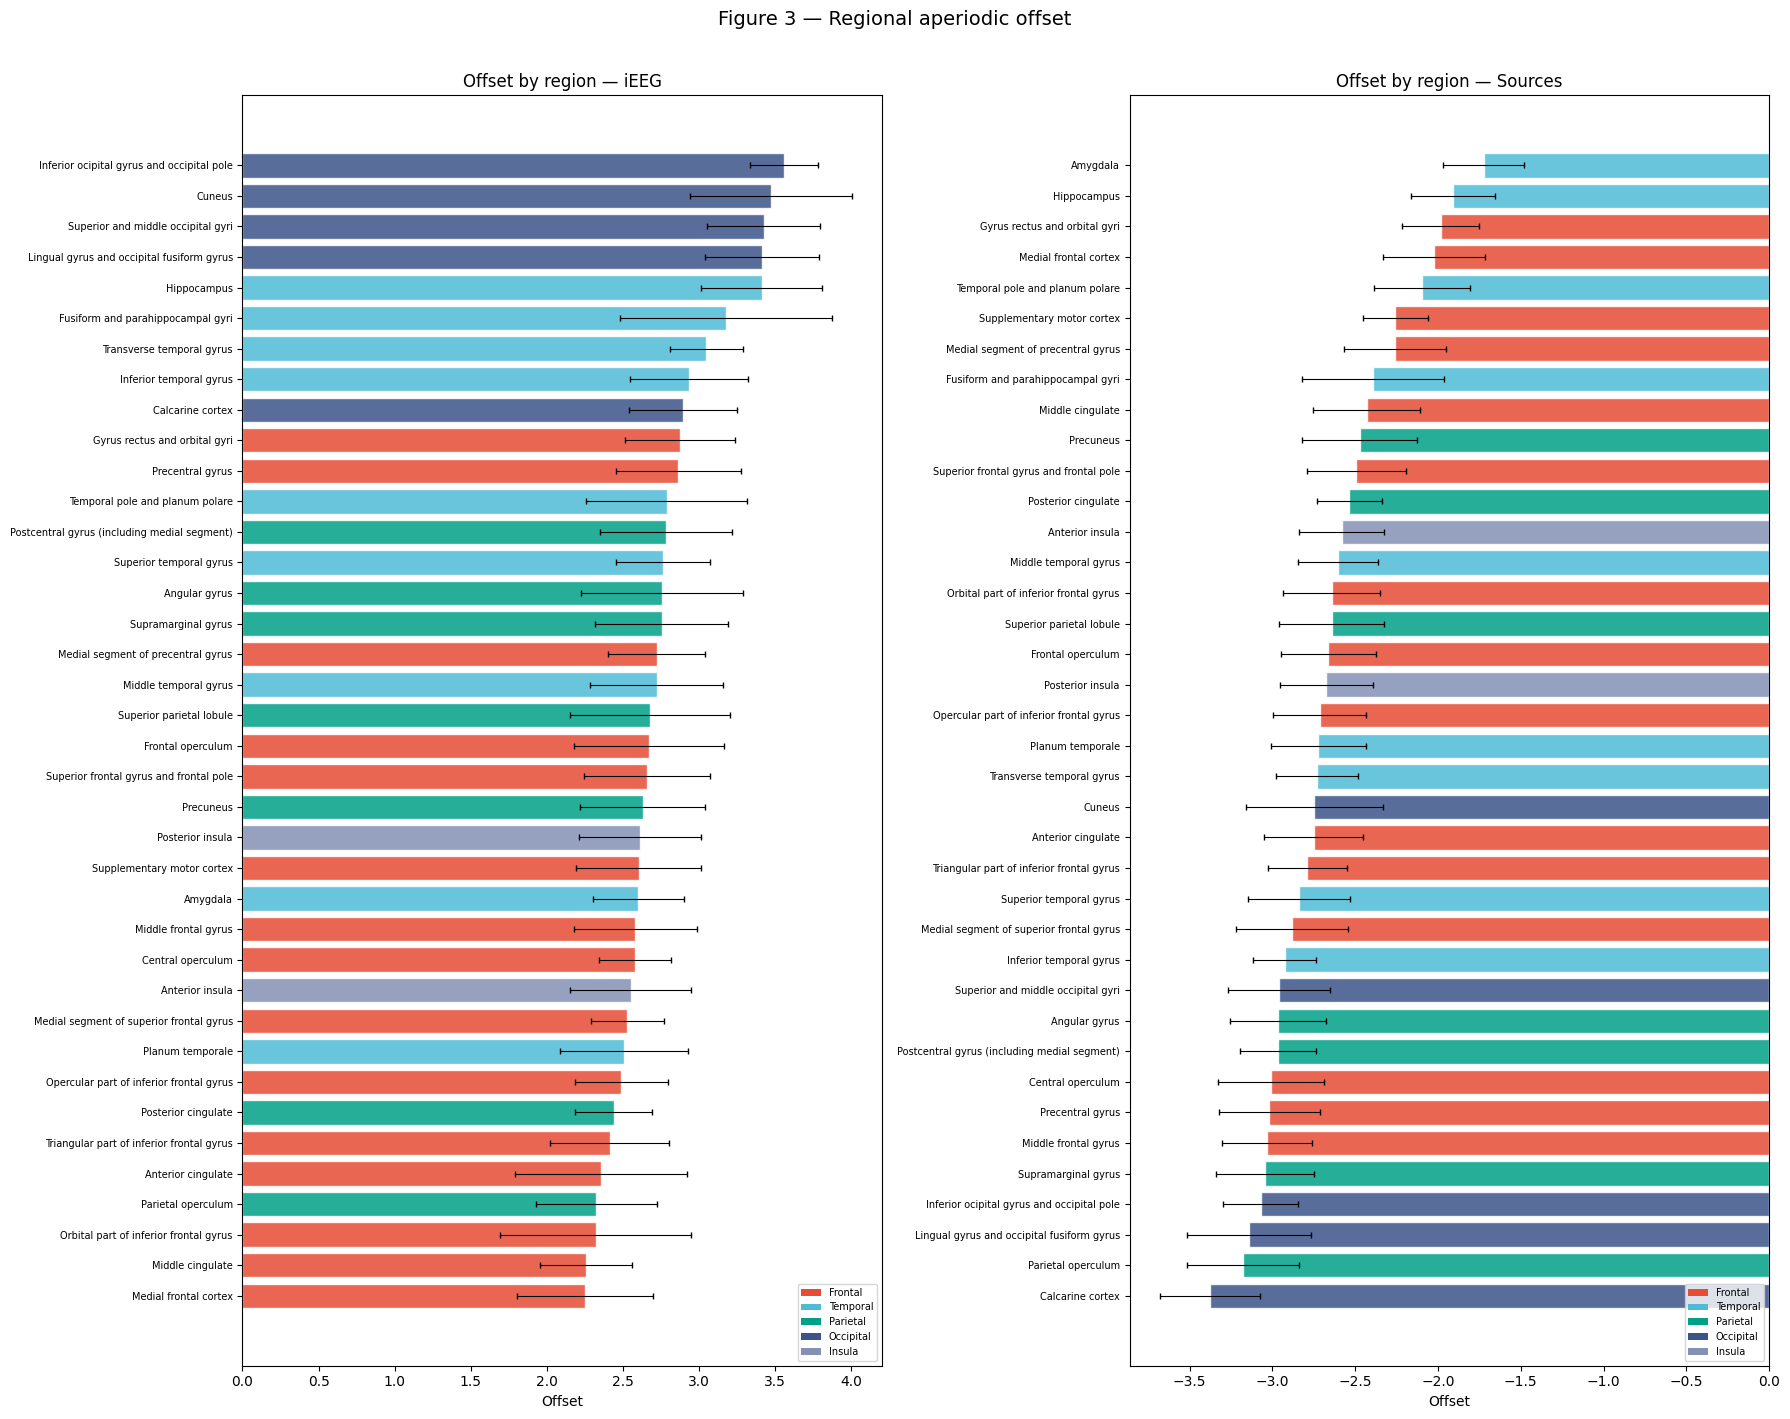

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 14), sharey=False)

plot_region_bars(ieeg_region,    param="offset", title="Offset by region — iEEG",    ax=ax1)
plot_region_bars(sources_region, param="offset", title="Offset by region — Sources", ax=ax2, show_n=False)

fig.suptitle("Figure 3 — Regional aperiodic offset", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "manuscript" / "figures" / "fig3_offset_by_region.svg",
            bbox_inches="tight", dpi=150)
plt.show()

## 4. Lobe-level summaries

In [6]:
def lobe_summary(region_df):
    return region_df.groupby("Lobe", as_index=False).agg(
        exponent_median = ("exponent_median", "median"),
        exponent_sd     = ("exponent_median", "std"),
        offset_median   = ("offset_median",   "median"),
        offset_sd       = ("offset_median",   "std"),
        n_regions       = ("Region name",     "count"),
    )

print("iEEG lobe summary:")
display(lobe_summary(ieeg_region).round(3))

print("Sources lobe summary:")
display(lobe_summary(sources_region).round(3))

iEEG lobe summary:


,Lobe,exponent_median,exponent_sd,offset_median,offset_sd,n_regions
0,Frontal,2.075,0.075,2.576,0.199,15
1,Insula,2.184,0.034,2.581,0.043,2
2,Occipital,2.327,0.173,3.423,0.262,5
3,Parietal,2.114,0.071,2.675,0.176,7
4,Temporal,2.239,0.155,2.786,0.288,9


Sources lobe summary:


,Lobe,exponent_median,exponent_sd,offset_median,offset_sd,n_regions
0,Frontal,1.062,0.136,-2.661,0.346,15
1,Insula,1.118,0.075,-2.628,0.066,2
2,Occipital,0.938,0.062,-3.071,0.232,5
3,Parietal,1.006,0.151,-2.966,0.276,7
4,Temporal,1.077,0.093,-2.602,0.433,9


## 5. Save region tables

In [7]:
ieeg_region.to_csv(INTERIM_DIR / "region_aperiodic_ieeg.csv", index=False)
sources_region.to_csv(INTERIM_DIR / "region_aperiodic_sources.csv", index=False)
print("Saved region summary tables.")

Saved region summary tables.
